# EDA Combined
Analyse exploratoire du dataset fusionné : GoodAir (Source A) + Open-Meteo (Source B).

## Imports et chargement

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Chargement des deux sources
df_goodair = pd.read_csv("../data/raw/goodair_historique/fact_mesures.csv")
df_openmeteo = pd.read_csv("../data/processed/open_meteo_combined.csv")

# Conversion temporelle
df_goodair["DateHeure"] = pd.to_datetime(df_goodair["DateHeure"])
df_openmeteo["time"] = pd.to_datetime(df_openmeteo["time"])
df_openmeteo = df_openmeteo.rename(columns={"time": "DateHeure"})

# tronquer les deux DateHeure à l'heure pour faciliter la fusion
df_goodair["DateHeure"] = pd.to_datetime(df_goodair["DateHeure"]).dt.floor("h")
df_openmeteo["DateHeure"] = pd.to_datetime(df_openmeteo["DateHeure"]).dt.floor("h")

print("Sources chargées.")
print(f"GoodAir   : {df_goodair.shape[0]} lignes")
print(f"Open-Meteo: {df_openmeteo.shape[0]} lignes")

Sources chargées.
GoodAir   : 10544 lignes
Open-Meteo: 25608 lignes


## 1. Fusion des deux sources - INNER JOIN

> **Note importante sur les trous temporels**
>
> Le projet GoodAir s'appuie sur une infrastructure locale (ordinateur personnel). Bien que la collecte ait été très régulière sur 3 mois, un tel matériel ne peut garantir une disponibilité 24/7 (déplacements, mises en veille, week-ends d'absence etc...). Notre historique comporte donc inévitablement quelques trous temporels.
>
> **Choix de jointure : INNER JOIN sur (NomVille, DateHeure)**
>
> Nous utilisons un INNER JOIN entre GoodAir (incomplet) et Open-Meteo (complet à 100%). Les heures où le pipeline GoodAir était éteint sont naturellement exclues du dataset final. Le volume sera légèrement réduit mais le dataset restera composé à 100% de vérité terrain (Ground Truth). Nous avons délibérément choisi de ne générer aucune donnée synthétique pour combler ces trous afin de préserver l'intégrité scientifique du projet.
>
exemple:
```bash
GoodAir contient :
2026-03-29 00:00  Paris  AQI=35
2026-03-29 03:00  Paris  AQI=40
# 01:00 et 02:00 n'existent pas du tout

Open-Meteo contient :
2026-03-29 00:00  Paris  wind=270
2026-03-29 01:00  Paris  wind=265
2026-03-29 02:00  Paris  wind=260
2026-03-29 03:00  Paris  wind=255
```

In [9]:
df = pd.merge(
    df_goodair,
    df_openmeteo[
        ["NomVille", "DateHeure", "wind_direction_10m", "cloud_cover", "precipitation"]
    ],
    on=["NomVille", "DateHeure"],
    how="inner",
)

# Feature dérivée
df["IsWeekend"] = df["DateHeure"].dt.weekday >= 5

print(f"Lignes avant fusion (GoodAir)   : {len(df_goodair)}")
print(f"Lignes après fusion (Combined)  : {len(df)}")
print(f"Lignes exclues (trous temporels): {len(df_goodair) - len(df)}")

# Sauvegarde
df.to_csv("../data/processed/dataset_combined.csv", index=False)
print("Dataset combiné sauvegardé.")

Lignes avant fusion (GoodAir)   : 10544
Lignes après fusion (Combined)  : 10544
Lignes exclues (trous temporels): 0
Dataset combiné sauvegardé.


### Observations - Fusion
Aucune ligne n'a été perdue.
**Deux explications possibles:**
- **Explication 1:** Open-Meteo Archive couvre exactement la même période que GoodAir (2026-03-29 → 2026-07-03) et est complet à 100%. Donc chaque heure de GoodAir a son équivalent Open-Meteo.(c'est exatement ce que nous avos faait lors du téléchargement des données Open-Meteo, nous avons choisi la même période que GoodAir)
- **Explication 2:** Le `dt.floor('h')` a bien aligné les timestamps. Sans ça on aurait probablement eu beaucoup de lignes exclues à cause des millisecondes.
exemple :
```bash
heure de GoodAir : 2026-03-29 00:00:00.000
heure de Open-Meteo : 2026-03-29 00:00:00
```
lorsqu'on applique le `dt.floor('h')` sur les deux colonnes, on obtient :
```bash
heure de GoodAir : 2026-03-29 00:00:00
heure de Open-Meteo : 2026-03-29 00:00:00
```
**Conclusion** GoodAir a 10544 heures collectées sur la période. Pour chacune de ces 10544 heures. Open-Meteo avait la donnée correspondante. Donc 0 perte lors de la fusion.

## 2. Description - Dimensionnalité

In [10]:
print(f"Lignes   : {df.shape[0]}")
print(f"Colonnes : {df.shape[1]}")
print()
print("Types de colonnes :")
print(df.dtypes)

Lignes   : 10544
Colonnes : 19

Types de colonnes :
NomVille                         str
DateHeure             datetime64[us]
Heure                          int64
Mois                           int64
Temperature                  float64
Humidite                       int64
Pression                       int64
VitesseVent                  float64
AqiGlobal                    float64
PM25                         float64
PM10                         float64
NO2                          float64
O3                           float64
MeteoStatus                      str
AirStatus                        str
wind_direction_10m             int64
cloud_cover                    int64
precipitation                float64
IsWeekend                       bool
dtype: object


### Observations - Dimensionnalité
> Le dataset combiné contient 10 544 lignes et 18 colonnes. Les 15 colonnes originales de GoodAir sont complétées par 3 nouvelles colonnes Open-Meteo : wind_direction_10m, cloud_cover et precipitation. Aucune ligne n'a été perdue lors de la fusion, ce qui confirme la cohérence temporelle entre les deux sources. Le dataset est maintenant prêt pour l'analyse croisée météo et qualité de l'air.

## 3. Description - Types de variables

In [4]:
qualitatives = ["NomVille", "IsWeekend", "MeteoStatus", "AirStatus"]
continues = [
    "Temperature",
    "Humidite",
    "Pression",
    "VitesseVent",
    "AqiGlobal",
    "PM25",
    "PM10",
    "NO2",
    "O3",
    "wind_direction_10m",
    "cloud_cover",
    "precipitation",
]
discretes = ["Heure", "Mois"]

print("Qualitatives :", qualitatives)
print("Continues    :", continues)
print("Discrètes    :", discretes)

Qualitatives : ['NomVille', 'IsWeekend', 'MeteoStatus', 'AirStatus']
Continues    : ['Temperature', 'Humidite', 'Pression', 'VitesseVent', 'AqiGlobal', 'PM25', 'PM10', 'NO2', 'O3', 'wind_direction_10m', 'cloud_cover', 'precipitation']
Discrètes    : ['Heure', 'Mois']


### Observations - Types de variables
> Le dataset combiné réunit 12 variables continues, 4 variables qualitatives et 2 variables discrètes. Par rapport aux notebooks précédents, 3 nouvelles variables continues apparaissent : wind_direction_10m, cloud_cover et precipitation, issues d'Open-Meteo. IsWeekend est maintenant visible comme variable qualitative car elle était déjà présente dans GoodAir. La richesse du dataset combiné est notable : on dispose à la fois des métriques de pollution, des métriques météo standard et des métriques météo complémentaires pour alimenter le modèle.

## 4. Description - Statistiques descriptives

In [11]:
stats = df[continues].agg(
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        "max",
        "sum",
    ]
)
stats.index = ["count", "mean", "median", "std", "min", "Q1", "Q3", "max", "sum"]
stats.round(2)

# Sauvegarde des statistiques descriptives
stats.to_csv("../data/processed/stats_descriptives_continues_dataset.csv")

### Observations - Statistiques descriptives

Les variables GoodAir conservent exactement les mêmes statistiques que dans le notebook 01, ce qui confirme que la fusion n'a pas altéré les données originales.

**Nouveautés apportées par Open-Meteo :**

- wind_direction_10m: moyenne à 190° et médiane à 207° confirmant les vents dominants du Sud sur la période. L'écart type de 112° montre une forte variabilité directionnelle.
- cloud_cover: moyenne de 49% et médiane de 44%. Q1 à 5% et Q3 à 97% confirment la distribution bimodale observée dans le notebook 02 : le ciel est soit très dégagé soit très couvert.
- precipitation: médiane et Q3 à 0 mm confirment que plus de 75% des heures n'ont aucune précipitation. La somme totale de 938.6 mm sur toute la période et toutes les villes représente en moyenne environ 85 mm par ville sur 3 mois. ce qui est cohérent avec les normales climatiques printanières françaises. Le maximum passe de 13.9 mm dans le notebook 02 à 11.4 mm ici car les données Open-Meteo sont maintenant filtrées sur les heures présentes dans GoodAir uniquement.

## 5. Description - Taux de NULL par colonne

Taux de NULL (%) par colonne :
O3           16.43
PM25          8.16
AqiGlobal     0.17
PM10          0.02
NO2           0.01
dtype: float64


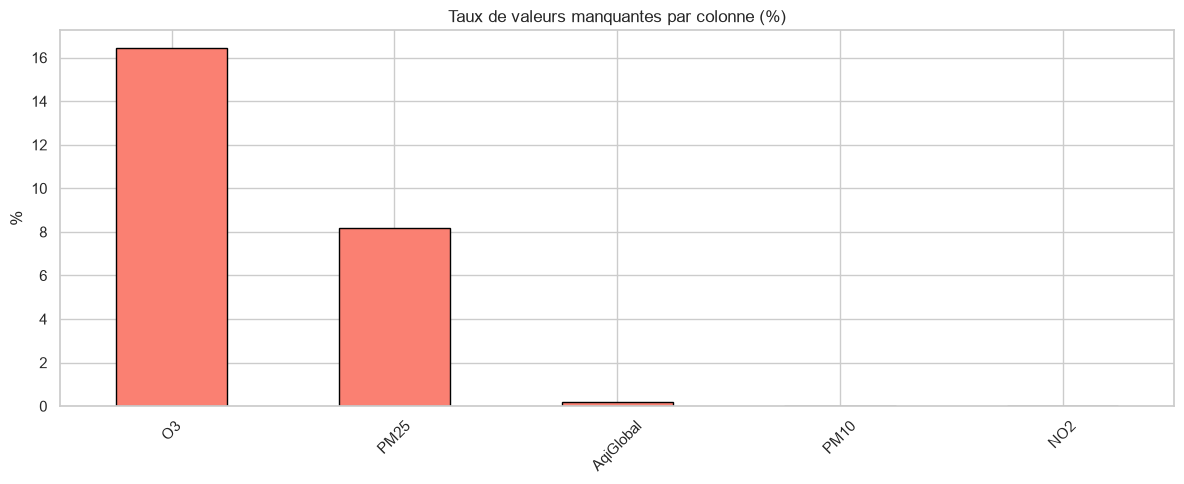

In [12]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print("Taux de NULL (%) par colonne :")
print(null_pct.round(2))

null_pct.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Taux de valeurs manquantes par colonne (%)")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations - Valeurs NULL
- Le graphique est identique à celui du notebook 01. Les trois colonnes Open-Meteo (wind_direction_10m, cloud_cover, precipitation) n'apparaissent pas car elles sont complètes à 100%, ce qui confirme l'apport d'Open-Meteo : zéro valeur manquante sur ses variables.
- O3 reste la colonne la plus impactée (16.43%) et PM25 la deuxième (8.16%), pour les mêmes raisons documentées précédemment (Lyon et Franconville sans capteurs). La fusion n'a introduit aucun nouveau NULL dans le dataset.

## 6. Description - Doublons

In [7]:
doublons = df.duplicated(subset=["NomVille", "DateHeure"]).sum()
print(f"Doublons sur (NomVille, DateHeure) : {doublons}")

Doublons sur (NomVille, DateHeure) : 0


### Observations - Doublons
> Aucun doublon détecté sur la clé (NomVille, DateHeure). C'est le résultat attendu car le `MERGE SQL Server` garantit déjà l'unicité de cette clé dans `Gold.FactMesures` via la contrainte PRIMARY KEY. La fusion `INNER JOIN` avec Open-Meteo n'a pas créé de duplication. Le dataset combiné est propre et prêt pour la suite.

## 7. Description - Fréquences

In [ ]:
print("Fréquences par NomVille")
print(df["NomVille"].value_counts())
print()
print("Fréquences par Heure")
print(df["Heure"].value_counts().sort_index())
print()
print("Fréquences par Mois")
print(df["Mois"].value_counts().sort_index())
print()
print("Fréquences IsWeekend")
print(df["IsWeekend"].value_counts())

Fréquences par NomVille
NomVille
Bordeaux        968
Lille           968
Lyon            968
Marseille       968
Nantes          968
Nice            968
Paris           968
Rennes          968
Strasbourg      968
Toulouse        968
Franconville    864
Name: count, dtype: int64

Fréquences par Heure
Heure
0     456
1     368
2     291
3     271
4     271
5     273
6     240
7     317
8     293
9     457
10    533
11    556
12    546
13    578
14    622
15    633
16    600
17    502
18    492
19    469
20    437
21    403
22    457
23    479
Name: count, dtype: int64

Fréquences par Mois
Mois
3     440
4    3339
5    3553
6    2728
7     484
Name: count, dtype: int64

Fréquences IsWeekend
IsWeekend
False    8966
True     1578
Name: count, dtype: int64


### Observations - Fréquences
- Les fréquences par ville. heure et mois sont identiques au notebook 01, ce qui confirme que la fusion n'a perdu aucune ligne.
- **Nouveauté : IsWeekend**
- 8966 mesures en semaine contre 1578 le week-end. Le ratio est d'environ 85% semaine et 15% week-end. Ce déséquilibre est normal et reflète la répartition naturelle des jours dans une semaine (5 jours ouvrés sur 7). Il n'y a pas de biais de collecte sur ce point. les week-ends sont bien représentés proportionnellement à leur occurrence réelle sur 3 mois.

## 8. Visualisation - Distribution (histogrammes variables continues)

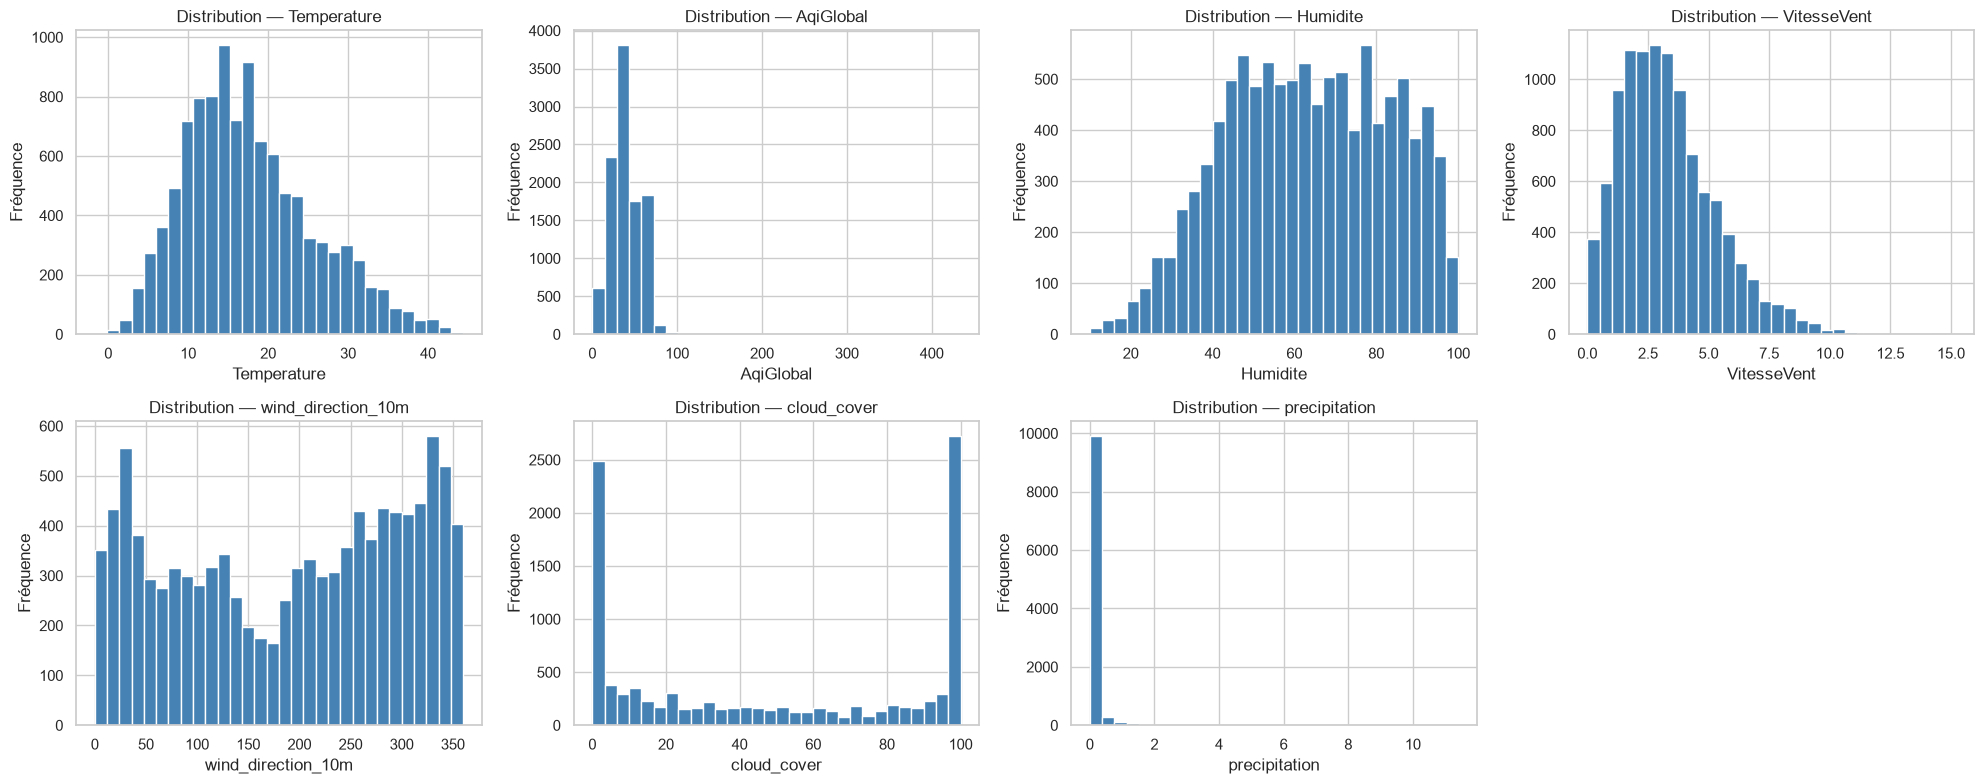

In [14]:
cols_hist = [
    "Temperature",
    "AqiGlobal",
    "Humidite",
    "VitesseVent",
    "wind_direction_10m",
    "cloud_cover",
    "precipitation",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cols_hist):
    df[col].dropna().plot(
        kind="hist", bins=30, ax=axes[i], color="steelblue", edgecolor="white"
    )
    axes[i].set_title(f"Distribution — {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Fréquence")

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Observations - Distribution
- Les distributions des variables GoodAir sont identiques aux observations du notebook 01 : température asymétrique à droite, AqiGlobal très concentré entre 0 et 100 avec une longue queue, VitesseVent asymétrique à droite avec pic entre 1 et 4 m/s.
- **Conclusion générale:** le dataset combiné ne présente aucune anomalie de distribution. Les deux sources se complètent sans se contredire. Les distributions asymétriques de AqiGlobal et precipitation confirment la nécessité de la winsorisation et de la binarisation prévues dans 04_data_preparation.ipynb.

## 9. Comparaison - AQI par ville et par source

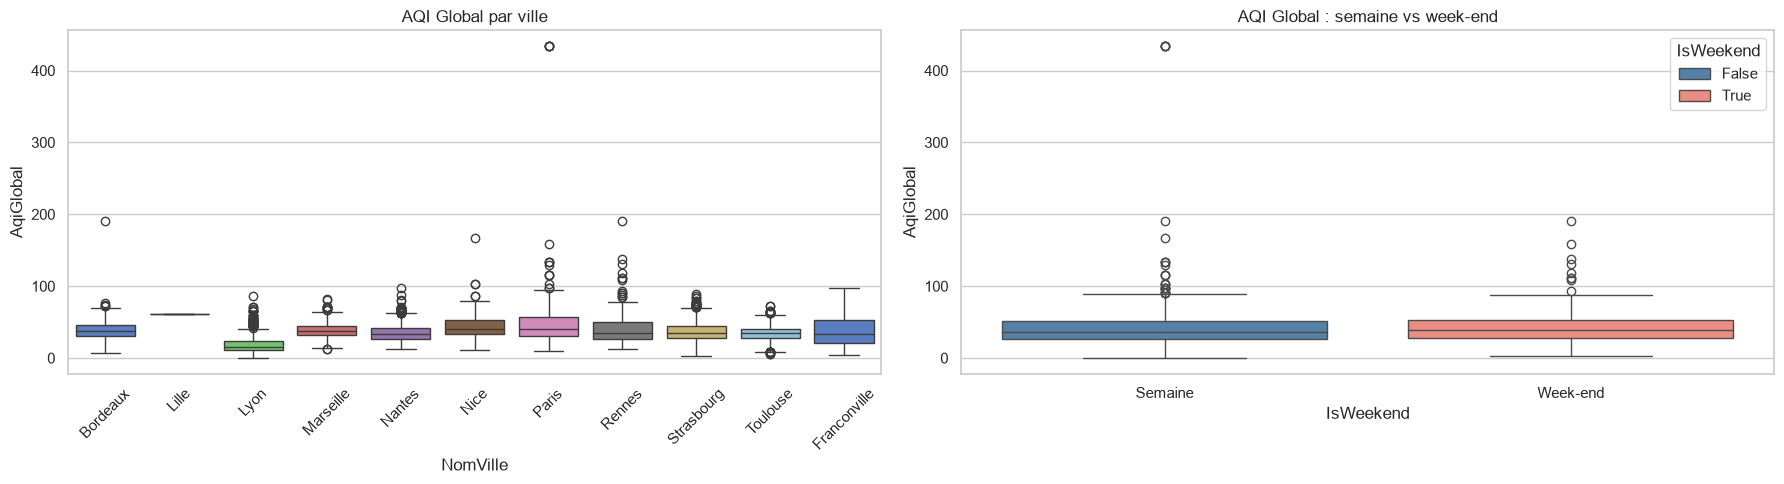

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(
    data=df, x="NomVille", y="AqiGlobal", ax=axes[0], palette="muted", hue="NomVille"
)
axes[0].set_title("AQI Global par ville")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df,
    x="IsWeekend",
    y="AqiGlobal",
    ax=axes[1],
    palette=["steelblue", "salmon"],
    hue="IsWeekend",
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Semaine", "Week-end"])
axes[1].set_title("AQI Global : semaine vs week-end")

plt.tight_layout()
plt.show()

### Observations - Comparaison AQI
- Les observations sont cohérentes avec ce qu'on avait vu dans le notebook 01. Le dataset combiné ne modifie pas les distributions AQI car Open-Meteo n'ajoute que des features météo complémentaires sans toucher à la variable cible.
- **Par ville**: Paris concentre toujours le plus d'outliers et le pic extrême à 434. Rennes et Bordeaux ont des outliers notables au-dessus de 150. Lyon reste la ville avec la médiane la plus basse et la boîte la plus compacte. Strasbourg présente une boîte très resserrée vers 0 avec une moustache basse proche de 0 — ce qui correspond à ses nombreux épisodes FAILED documentés en notebook 01.
- **Semaine vs week-end**: les deux boîtes restent quasi identiques avec des médianes similaires autour de 40. Le pic extrême à 434 apparaît des deux côtés. Aucune différence significative ne se dégage visuellement. ce qui confirme l'observation du notebook 01 : IsWeekend a un pouvoir prédictif limité sur l'AqiGlobal dans notre dataset.

## 10. Relations - variables météo vs AQI

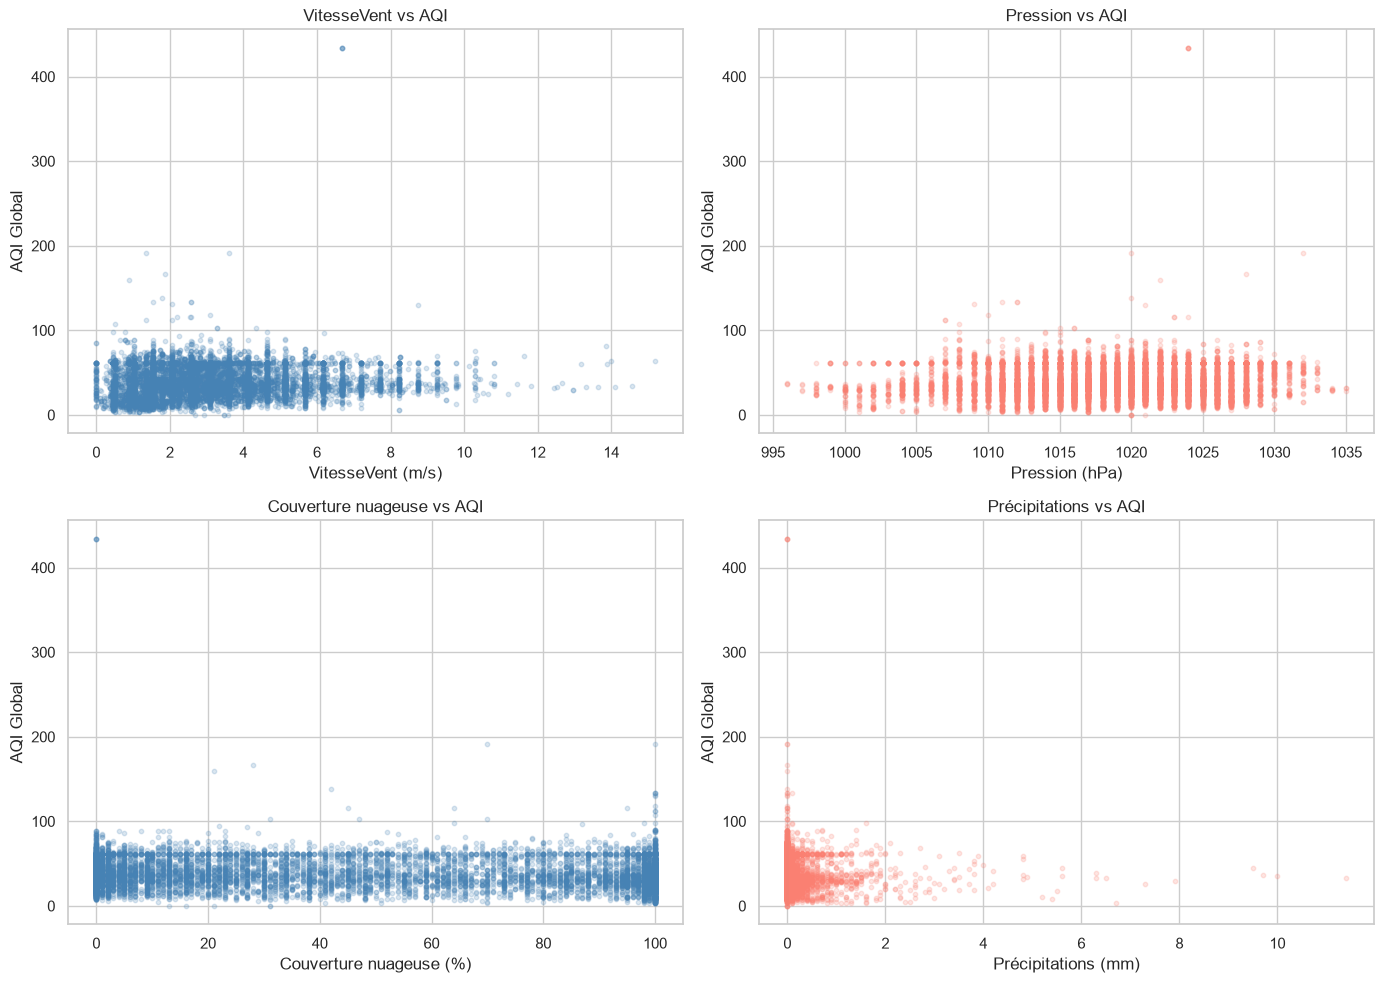

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# VitesseVent vs AqiGlobal
axes[0, 0].scatter(
    df["VitesseVent"], df["AqiGlobal"], alpha=0.2, color="steelblue", s=10
)
axes[0, 0].set_xlabel("VitesseVent (m/s)")
axes[0, 0].set_ylabel("AQI Global")
axes[0, 0].set_title("VitesseVent vs AQI")

# Pression vs AqiGlobal
axes[0, 1].scatter(df["Pression"], df["AqiGlobal"], alpha=0.2, color="salmon", s=10)
axes[0, 1].set_xlabel("Pression (hPa)")
axes[0, 1].set_ylabel("AQI Global")
axes[0, 1].set_title("Pression vs AQI")

# cloud_cover vs AqiGlobal
axes[1, 0].scatter(
    df["cloud_cover"], df["AqiGlobal"], alpha=0.2, color="steelblue", s=10
)
axes[1, 0].set_xlabel("Couverture nuageuse (%)")
axes[1, 0].set_ylabel("AQI Global")
axes[1, 0].set_title("Couverture nuageuse vs AQI")

# precipitation vs AqiGlobal
axes[1, 1].scatter(
    df["precipitation"], df["AqiGlobal"], alpha=0.2, color="salmon", s=10
)
axes[1, 1].set_xlabel("Précipitations (mm)")
axes[1, 1].set_ylabel("AQI Global")
axes[1, 1].set_title("Précipitations vs AQI")

plt.tight_layout()
plt.show()

### Observations - Relations météo vs AQI
- **VitesseVent vs AQI:** même observation que le notebook 01. pas de relation linéaire claire. Les valeurs AQI élevées (au-dessus de 100) se concentrent pour des vents faibles à modérés (0 à 8 m/s). Le pic extrême à 434 apparaît à environ 6 m/s. ce qui est surprenant car un vent fort devrait disperser les polluants. Cela suggère que cet événement extrême est lié à d'autres facteurs que le vent seul.
- **Pression vs AQI:** nuage de points très dense et homogène sur toute la plage 996 à 1035 hPa. Aucune tendance linéaire visible. Le pic à 434 apparaît à environ 1025 hPa (situation anticyclonique) ce qui est cohérent avec la théorie : un anticyclone piège les polluants au sol. Mais la relation n'est pas systématique sur l'ensemble du dataset.
- **Couverture nuageuse vs AQI:** distribution très homogène sur toute la plage 0 à 100%. L'AQI ne semble pas varier significativement selon que le ciel est dégagé ou couvert. Le pic à 434 apparaît à 0% de couverture nuageuse. ce qui renforce l'hypothèse d'un événement de pollution par temps anticyclonique et ensoleillé.
- **Précipitations vs AQI:** relation intéressante. Les AQI les plus élevés (au-dessus de 100) sont quasi exclusivement associés à 0 mm de précipitation. Quand il pleut, l'AQI reste bas. Le pic à 434 apparaît à 0 mm. On observe également que les AQI diminuent progressivement quand les précipitations augmentent au-delà de 1 mm. C'est la relation "lavage de l'air" attendue et c'est la relation la plus nette parmi les quatre graphiques.
- **Conclusion générale:** aucune des quatre variables n'explique seule l'AQI de façon linéaire. C'est précisément pour cette raison que Random Forest et XGBoost sont mieux adaptés que la régression linéaire. ils peuvent capturer ces relations non linéaires et les interactions entre variables.

## 11. Distribution temporelle - AQI moyen par heure et évolution mensuelle

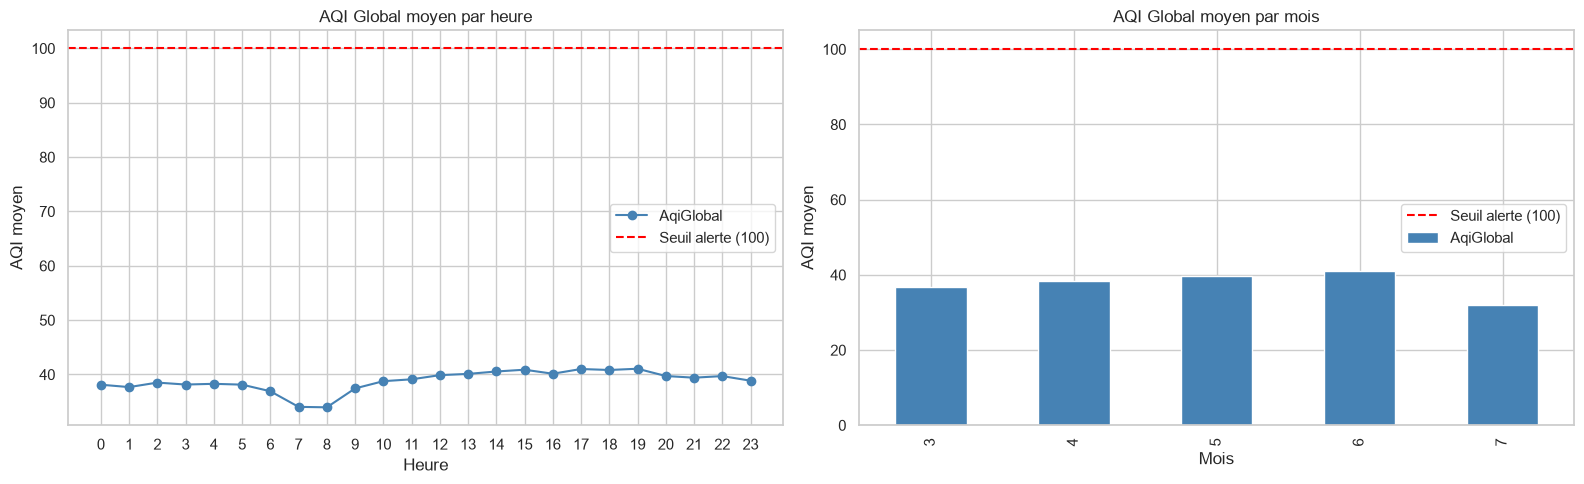

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# AQI moyen par heure
aqi_by_hour = df.groupby("Heure")["AqiGlobal"].mean()
aqi_by_hour.plot(kind="line", marker="o", color="steelblue", ax=axes[0])
axes[0].axhline(y=100, color="red", linestyle="--", label="Seuil alerte (100)")
axes[0].set_title("AQI Global moyen par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("AQI moyen")
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# AQI moyen par mois
aqi_by_month = df.groupby("Mois")["AqiGlobal"].mean()
aqi_by_month.plot(kind="bar", color="steelblue", edgecolor="white", ax=axes[1])
axes[1].axhline(y=100, color="red", linestyle="--", label="Seuil alerte (100)")
axes[1].set_title("AQI Global moyen par mois")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("AQI moyen")
axes[1].legend()

plt.tight_layout()
plt.show()

### Observations - Distribution temporelle
- **AQI moyen par heure:** identique au notebook 01. La courbe est stable entre 36 et 42 sur toute la journée sans pic horaire marqué. Le creux entre 7h et 8h persiste et s'explique toujours par les trous temporels à ces heures. Aucun dépassement du seuil d'alerte à 100 sur les moyennes horaires.
- **AQI moyen par mois:** nouvelle visualisation par rapport aux notebooks précédents. L'AQI moyen augmente progressivement de mars (38) à juin (41) puis redescend en juillet (33). Cette légère tendance à la hausse de mars à juin correspond à la montée en température et au développement de l'ozone photochimique au printemps. La baisse de juillet peut s'expliquer par les précipitations plus fréquentes en début juillet ou par le fait que juillet n'est représenté que sur quelques jours.
- **Conclusion:** la variable Mois capture une tendance saisonnière subtile mais réelle. Son encodage sin/cos dans la préparation des données est justifié. La variable Heure reste peu discriminante sur les moyennes mais peut capturer des patterns fins non visibles ici.

## 12. Composition - Contribution des villes aux pics de pollution

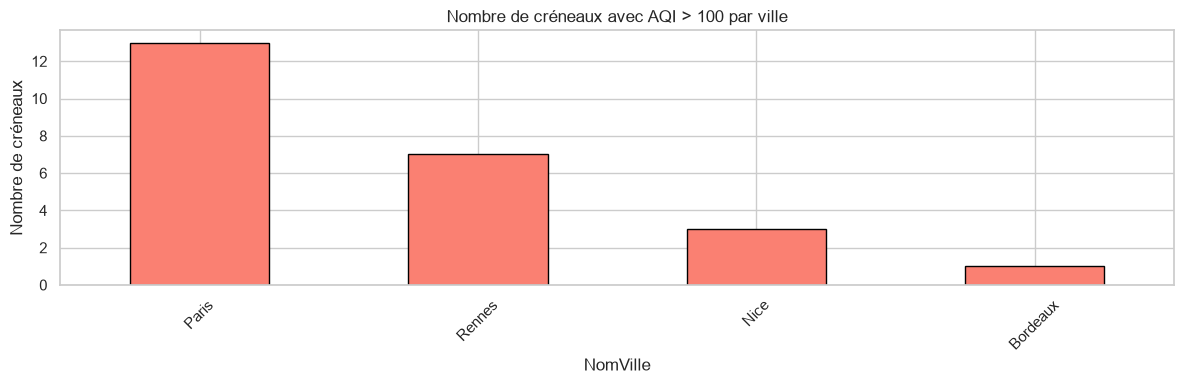

Total créneaux avec AQI > 100 : 24
Pourcentage du dataset        : 0.2%


In [20]:
# Villes avec AQI > 100
pics = df[df["AqiGlobal"] > 100]
pics_by_city = pics["NomVille"].value_counts()

pics_by_city.plot(kind="bar", color="salmon", edgecolor="black", figsize=(12, 4))
plt.title("Nombre de créneaux avec AQI > 100 par ville")
plt.ylabel("Nombre de créneaux")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total créneaux avec AQI > 100 : {len(pics)}")
print(f"Pourcentage du dataset        : {len(pics) / len(df) * 100:.1f}%")

### Observations - Pics de pollution
- Seulement 24 créneaux sur 10 544 dépassent le seuil d'alerte de 100, soit 0.2% du dataset. Les épisodes de pollution sévère sont donc des événements rares mais réels.
- Paris est la ville la plus concernée avec 13 créneaux au-dessus de 100, soit plus de la moitié de tous les dépassements. Rennes suit avec 7 créneaux, ce qui est surprenant pour une ville de taille moyenne. Nice en a 3 et Bordeaux 1.
- 7 villes sur 11 n'ont jamais dépassé le seuil de 100 sur toute la période : Lyon, Lille, Marseille, Nantes, Strasbourg, Toulouse et Franconville. Cette information est importante pour le modèle car les exemples positifs (AQI > 100) sont très peu nombreux et concentrés sur 4 villes. Le modèle devra apprendre à partir de très peu d'exemples de dépassement. ce qui renforce l'importance de la précision des alertes comme métrique complémentaire au R-carré.
- **Conclusion:** la règle métier AQI > 100 = ALERTE est pertinente mais rare dans nos données. Le modèle sera naturellement entraîné à prédire des AQI bas. Il faudra surveiller de près les faux négatifs (alertes manquées) dans le notebook 06.

## 13. Matrice de corrélation - Dataset combiné complet

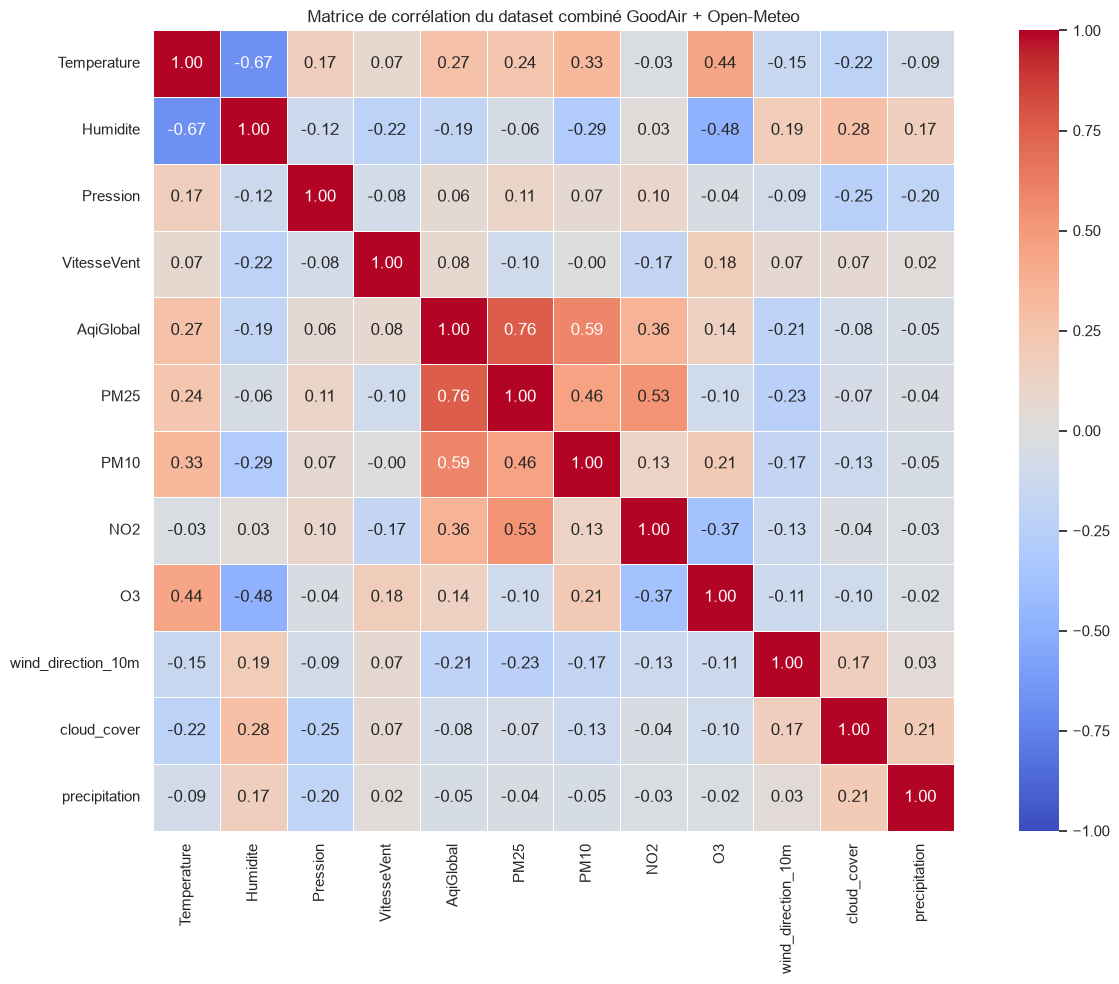

In [21]:
corr = df[continues].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Matrice de corrélation du dataset combiné GoodAir + Open-Meteo")
plt.tight_layout()
plt.show()

### Observations - Corrélations combinées
- PM25 reste la feature la plus corrélée avec AqiGlobal (0.76) suivie de PM10 (0.59). Temperature (0.27) et NO2 (0.36) apportent un signal modéré.
- Les trois variables Open-Meteo ont des corrélations faibles avec AqiGlobal : wind_direction_10m à -0.21. cloud_cover à -0.08 et precipitation à -0.05. Ces corrélations faibles ne signifient pas que ces variables sont inutiles. Random Forest et XGBoost peuvent capturer des relations non linéaires et des interactions que la corrélation de Pearson ne détecte pas.
- **Relations entre variables Open-Meteo et GoodAir:**
- wind_direction_10m est négativement corrélée avec Temperature (-0.15) et positivement avec Humidite (0.19). Les vents du Nord apportent de l'air froid et humide, ce qui est cohérent physiquement.
- cloud_cover est négativement corrélée avec Temperature (-0.22) et Pression (-0.25). Un ciel couvert correspond à des pressions plus basses et des températures plus fraîches. cohérent avec les systèmes dépressionnaires.
- cloud_cover est aussi positivement corrélée avec Humidite (0.28) quand le ciel est couvert l'air est plus humide. Relation physique logique.
- **Multicolinéarité:**
- Temperature et Humidite restent fortement corrélées (-0.67). C'est le seul couple avec une corrélation forte dans le dataset combiné. Les variables Open-Meteo n'introduisent aucune nouvelle multicolinéarité significative avec les variables GoodAir existantes.
- **Conclusion:** le dataset combiné est riche. 12 features continues avec des relations variées et complémentaires. Aucune redondance problématique entre les variables Open-Meteo et GoodAir. Les corrélations faibles des variables Open-Meteo avec AqiGlobal sont compensées par leur indépendance des autres features. ce qui enrichit le signal global du modèle.

## 14. Synthèse générale - EDA Combined

**Points clés à retenir pour la suite :**

- La fusion INNER JOIN s'est faite sans perte de lignes. 10 544 lignes à 100% de Ground Truth.
- Les deux sources sont complémentaires et sans contradiction. Open-Meteo n'introduit aucune multicolinéarité problématique avec GoodAir.
- Seules 4 villes sur 11 dépassent le seuil AQI > 100. les alertes sont des événements rares (0.2% du dataset). La précision des alertes sera une métrique critique en plus du R².
- Aucune relation linéaire forte entre les variables météo et AqiGlobal. ce qui confirme le choix de Random Forest et XGBoost.

**Variables avec NULL à surveiller :**

- O3 : 16.43% de NULL. Lyon (88.84%) et Franconville (100%) sans capteur ozone.
- PM25 : 8.16% de NULL. Lyon (88.84%) sans capteur PM25.
- Ces NULL sont conservés. Random Forest et XGBoost les gèrent nativement.

**Outliers détectés :**

- AqiGlobal : pic extrême à 434 sur Paris. valeurs au-dessus de 150 sur Rennes et Bordeaux. Winsorisation à 99% prévue dans 04_data_preparation.ipynb.
- PM10 : maximum à 434 qui coïncide avec le pic AqiGlobal. même événement de pollution.
- PM25 : maximum à 191. même traitement winsorisation.
- Variables Open-Meteo : aucun outlier problématique. leurs plages de valeurs sont physiquement correctes.

**Features retenues pour le modèle :**

- Temperature. Humidite. Pression. VitesseVent (GoodAir. météo standard)
- AqiGlobal (variable cible Y)
- wind_direction_10m. cloud_cover. precipitation (Open-Meteo. complémentaires)
- Heure. Mois (encodage sin/cos)
- IsWeekend (feature dérivée)
- NomVille (One-Hot Encoding)

**Features écartées et justification :**
- PM25, PM10, NO2 et O3 : ces variables sont les composantes directes de l'indice de qualité de l'air. Les utiliser comme features reviendrait à donner la réponse au modèle. De plus elles ne sont pas disponibles pour les heures futures et sont absentes pour certaines villes (Lyon, Franconville). Elles sont corrélées avec AqiGlobal dans l'historique mais ne peuvent pas servir à prédire l'AQI futur.
- MeteoStatus et AirStatus : colonnes d'audit pipeline. pas de valeur prédictive pour l'AQI futur.
- DateHeure : remplacée par Heure, Mois et IsWeekend.
- Features de lag (AQI_lag_1, rolling_mean_24h) : écartées à cause des trous temporels qui généreraient trop de NULL.